In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [ ]:
# Gather data and merge the wines together
df1 = pd.read_csv("winequality-white.csv", sep=";")
df2 = pd.read_csv("winequality-red.csv",   sep=";")
df1["color"] = "white"
df2["color"] = "red"
df = pd.concat([df1, df2], axis=0, ignore_index=True)
# We will aim to predict color using all of the features provided
y = df['color']
X = df.drop(['color'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, "values") else X_train_scaled
y_train_np = y_train.values      if hasattr(y_train,     "values") else y_train
y_train_np = y_train_np.ravel()
# Scale the features
scaler = StandardScaler()

## Results

1. **Cluster Separation**  
   - KMeans places the majority of “purple” points on the **lower-Feature 1** side and “yellow” points toward **higher-Feature 1** values.  
   - This matches the general trend in the actual labels: one wine type tends to have lower values of Feature 1.

2. **Alignment with True Classes**  
   - There is a clear—but not perfect—correspondence:  
     - Most of the purple cluster overlaps the true “purple” (e.g. red wine) region.  
     - Most of the yellow cluster aligns with the true “yellow” (e.g. white wine) region.  
   - However, some misassignments occur near the boundary (points with intermediate Feature 1), indicating overlap in the feature distributions.

3. **Cluster Cohesion & Overlap**  
   - The clusters are reasonably tight, especially in the dense central region (Feature 1 ≈ 5–9).  
   - Overlap in the scatter suggests that **Feature 1 & 2 alone** don’t fully separate the two classes; additional features or preprocessing (e.g. scaling, PCA) might improve unsupervised separation.

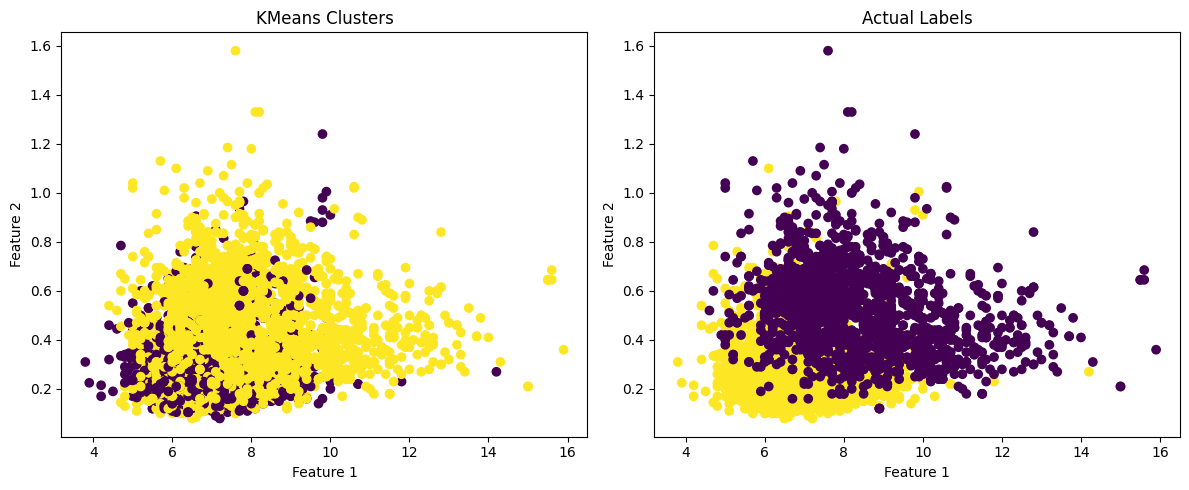

In [13]:
# If X is a pandas DataFrame, convert to NumPy array:
X_np = X.values  # shape (n_samples, n_features)

# 1. Perform KMeans clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_np)

# 2. Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: KMeans cluster assignments
axes[0].scatter(X_np[:, 0], X_np[:, 1], c=clusters, cmap='viridis')
axes[0].set_title("KMeans Clusters")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Right: Actual labels (assuming y is numeric 0/1 or categorical)
axes[1].scatter(X_np[:, 0], X_np[:, 1], c=y.map({'red':0,'white':1}) if y.dtype=='object' else y, cmap='viridis')
axes[1].set_title("Actual Labels")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Key Takeaways

**Residual Sugar & SO₂ Drive Cluster 0**  
   - Cluster 0 has **more than double** the residual sugar and ~2–3× the free & total sulfur dioxide compared to Cluster 1.  
   - These are hallmark traits of **white wines** (sweeter, higher SO₂).

**Acidity & Alcohol Point to Cluster 1**  
   - Cluster 1 exhibits **higher volatile acidity**, **higher alcohol**, and **higher sulphates**, consistent with many **red wines** (bolder acidity and tannin‐related compounds).  

**Quality Is Not a Separator**  
   - Both clusters share the same mean quality rating (~5.9).  The clustering captures chemical style differences rather than perceived quality.

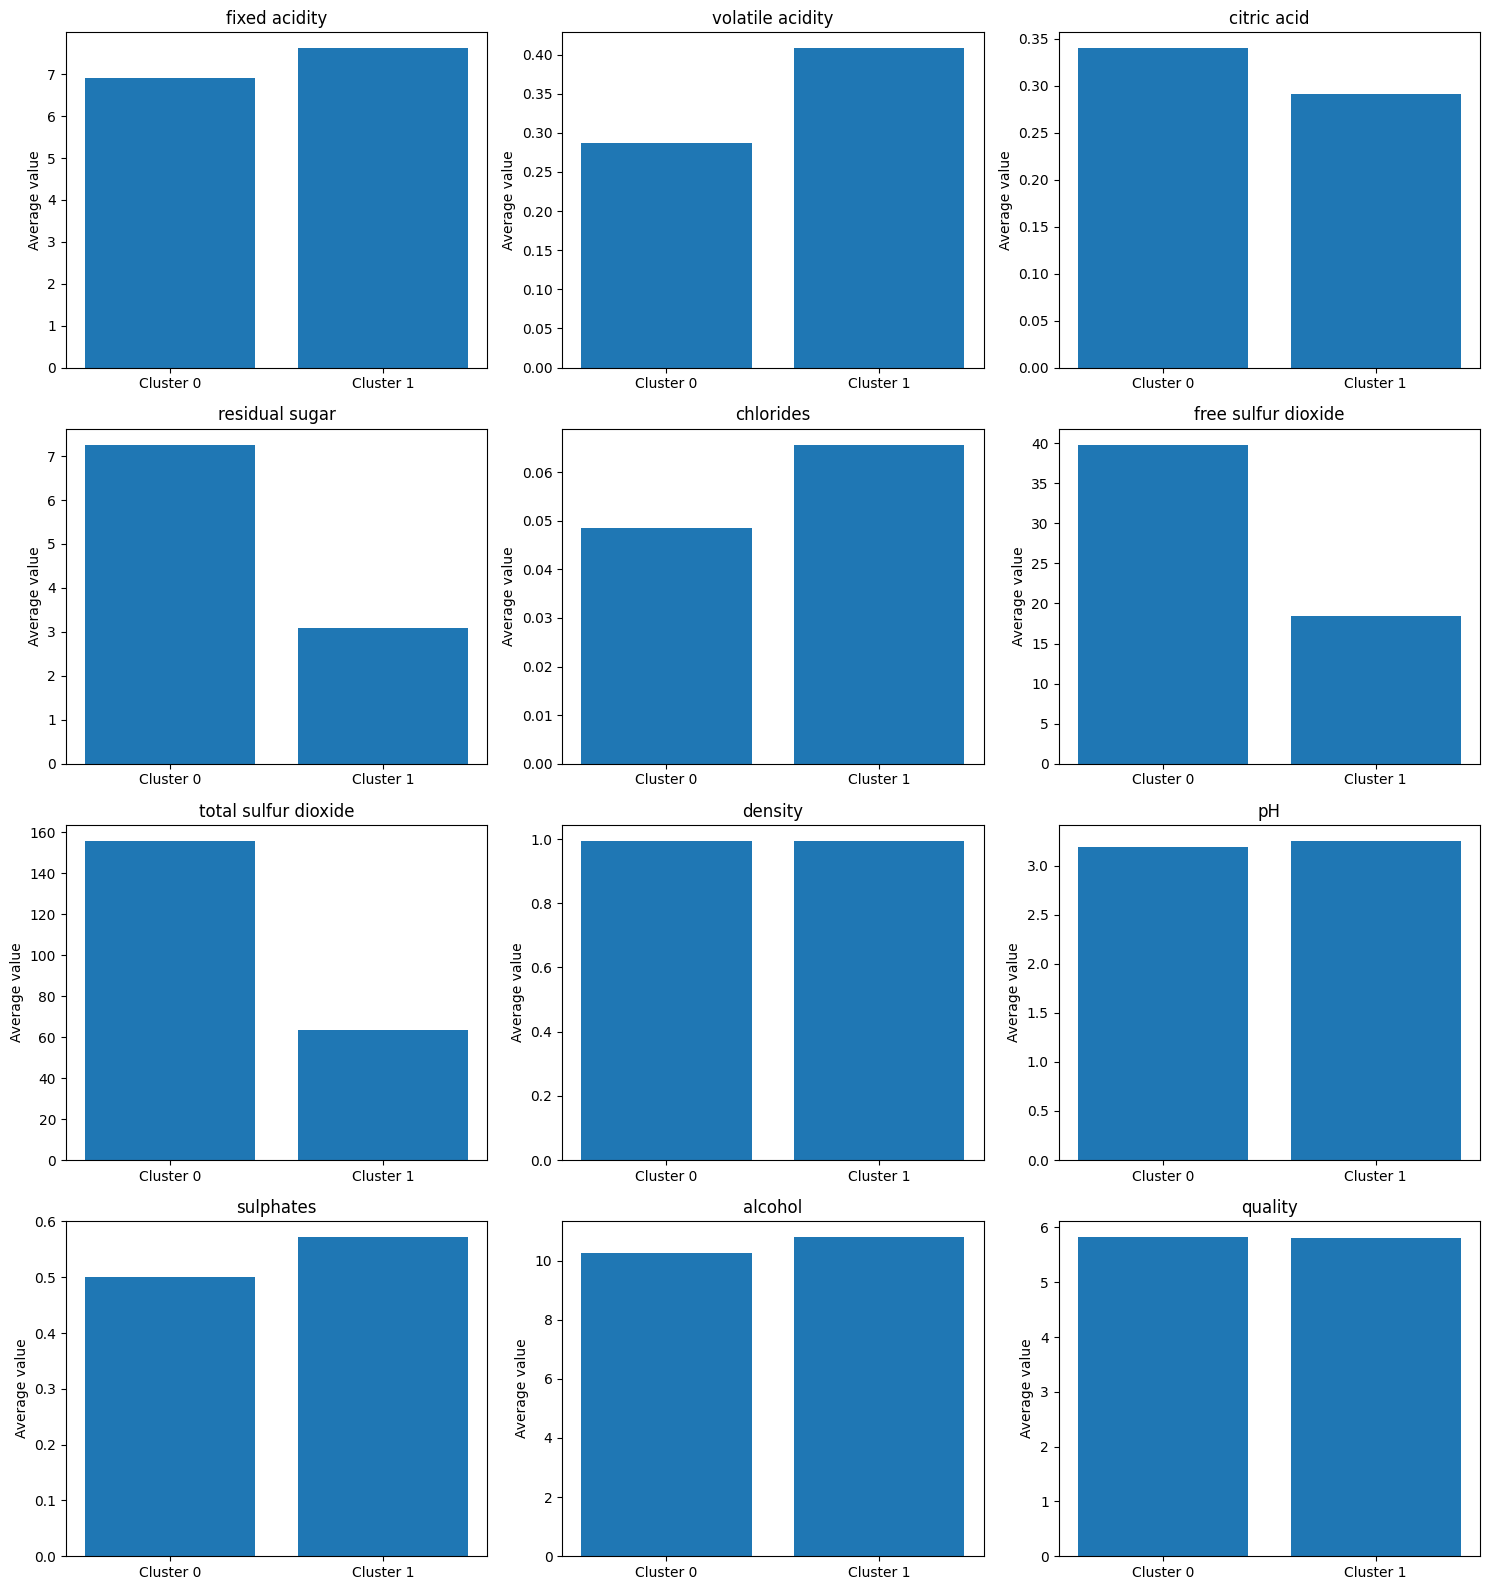

In [14]:
# Compute mean of each feature per cluster
X = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=df.columns)
X['cluster'] = clusters
means = X.groupby('cluster').mean()

# Plot bar charts for each feature
n_features = X.shape[1] - 1  # exclude 'cluster' column
cols = 3
rows = (n_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()
for idx, feature in enumerate(X.columns.drop('cluster')):
    axes[idx].bar([0, 1], means[feature])
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Cluster 0', 'Cluster 1'])
    axes[idx].set_ylabel('Average value')
    axes[idx].set_title(feature)

# Hide any unused subplots
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()